In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("RSMC_RAW.csv", index_col=0)
data = data.rename_axis('International number ID').reset_index()



# Convert the 'timestamp' column to datetime
data['Time of analysis'] = pd.to_datetime(data['Time of analysis'])

# Extract Year, Month, Day, and Hour into new columns
data['year'] = data['Time of analysis'].dt.year
data['month'] = data['Time of analysis'].dt.month
data['day'] = data['Time of analysis'].dt.day
data['hour'] = data['Time of analysis'].dt.hour

# Drop the unecessary columns
data = data.drop(columns=['Time of analysis'])
data = data.drop(columns=['Name of the storm'])

# Reposition
data.insert(2, 'year', data.pop('year'))
data.insert(3, 'month', data.pop('month'))
data.insert(4, 'day', data.pop('day'))
data.insert(5, 'hour', data.pop('hour'))

data.head()

,International number ID,Grade,year,month,day,hour,Latitude of the center,Longitude of the center,Central pressure,Maximum sustained wind speed,Direction of the longest radius of 50kt winds or greater,The longest radius of 50kt winds or greater,The shortest radius of 50kt winds or greater,Direction of the longest radius of 30kt winds or greater,The longest radius of 30kt winds or greater,The shortest radius of 30kt winds or greater,Indicator of landfall or passage
0,5101,Tropical Depression (TD),1951,2,19,6,20.0,138.5,1010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
1,5101,Tropical Depression (TD),1951,2,19,12,20.0,138.5,1010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
2,5101,Tropical Depression (TD),1951,2,19,18,23.0,142.1,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
3,5101,Tropical Cyclone of TS intensity or higher,1951,2,20,0,25.0,146.0,994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,5101,Tropical Cyclone of TS intensity or higher,1951,2,20,6,27.6,150.6,994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


In [ ]:
#drops unnecessary columns
data = data.drop(["Indicator of landfall or passage"], axis=1)


In [ ]:
# Drop rows before year 1977 since they used different method to grade and record typhoons
data = data[data["year"] >= 1977]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43482 entries, 25268 to 68749
Data columns (total 16 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   International number ID                                   43482 non-null  int64  
 1   Grade                                                     43482 non-null  object 
 2   year                                                      43482 non-null  int32  
 3   month                                                     43482 non-null  int32  
 4   day                                                       43482 non-null  int32  
 5   hour                                                      43482 non-null  int32  
 6   Latitude of the center                                    43482 non-null  float64
 7   Longitude of the center                                   43482 non-null  float64
 8   Central pressure 

In [ ]:
idx = data["Grade"]=="Just entering into the responsible area of RSMC Tokyo-Typhoon Center"
data[idx].shape

(28, 16)

In [ ]:
data = data.drop(data[idx].index)
data.shape

(43454, 16)

In [ ]:
data["Grade"].unique()

array(['Tropical Depression (TD)', 'Severe Tropical Storm (STS)',
       'Tropical Storm (TS)', 'Extra-tropical Cyclone (L)',
       'Typhoon (TY)'], dtype=object)

In [ ]:
data = data.replace("Tropical Depression (TD)", "TD")
data = data.replace("Severe Tropical Storm (STS)", "STS")
data = data.replace("Tropical Storm (TS)", "TS")
data = data.replace("Extra-tropical Cyclone (L)", "L")
data = data.replace("Typhoon (TY)", "TY")
data["Grade"].unique()

array(['TD', 'STS', 'TS', 'L', 'TY'], dtype=object)

In [ ]:
data[data["Direction of the longest radius of 50kt winds or greater"].isna()]["Grade"].unique()
data[data["Direction of the longest radius of 50kt winds or greater"].notna()]["Grade"].unique()

array(['STS', 'TS', 'TY'], dtype=object)

In [ ]:
data = data.dropna()
len(data)

27281

In [ ]:
data = data.drop(["Direction of the longest radius of 50kt winds or greater", "Direction of the longest radius of 30kt winds or greater"], axis=1)

In [ ]:
grade_map = {"TD":1, "TS":2, "STS":3, "TY":4}  # grade map using the standard for grade Tropical Depressions of WMO
data["Grade"] = data["Grade"].map(grade_map)

In [ ]:
data = data[data["hour"] % 6 == 0]

In [ ]:
data.head()
data.tail()

,International number ID,Grade,year,month,day,hour,Latitude of the center,Longitude of the center,Central pressure,Maximum sustained wind speed,The longest radius of 50kt winds or greater,The shortest radius of 50kt winds or greater,The longest radius of 30kt winds or greater,The shortest radius of 30kt winds or greater
68727,2303,3,2023,6,11,6,24.2,132.6,975,60.0,80.0,60.0,270.0,150.0
68728,2303,3,2023,6,11,12,25.6,133.8,980,55.0,80.0,60.0,300.0,150.0
68729,2303,3,2023,6,11,18,26.4,135.3,980,55.0,70.0,50.0,300.0,150.0
68730,2303,3,2023,6,12,0,27.9,136.9,980,55.0,60.0,40.0,300.0,150.0
68731,2303,3,2023,6,12,6,29.5,138.1,985,50.0,0.0,0.0,300.0,150.0


In [ ]:
ids = data["International number ID"].unique() # Unique IDs of typhoons
typhoons = list()
for ID in ids:
    typhoon = data[data["International number ID"] == ID]
    typhoon = typhoon.drop(["International number ID"], axis=1)
    typhoons.append(typhoon)
print(len(typhoons))

1177


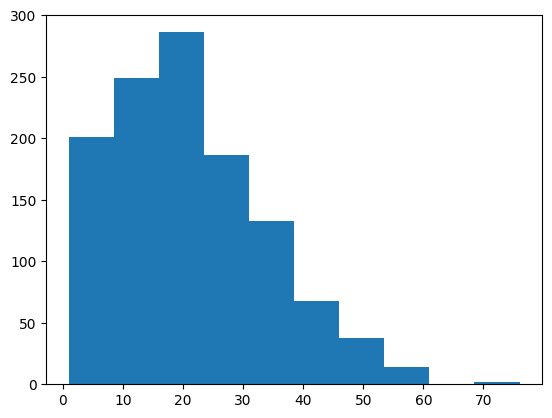

[201. 249. 286. 186. 133.  68.  38.  14.   0.   2.]


In [ ]:
hist = data["International number ID"].value_counts()
n = plt.hist(hist)
plt.show()
print(n[0])

In [ ]:
interval = 1
dataset = np.empty((0, 3, 13))
test_typhoons = np.empty((0,3,13))  # Preserve Some typhoons for model evaluation
count = 0

for typhoon in typhoons:
    nptyphoon = np.array(typhoon)
    for i in range(0, nptyphoon.shape[0]-3, interval):
        single_data = nptyphoon[i:i+3]
        single_data = np.expand_dims(single_data, axis=0)
        if typhoon.iloc[0]["year"]>=2022:
            count +=1
            test_typhoons = np.append(test_typhoons, single_data, axis=0)
            continue
        dataset = np.append(dataset, single_data, axis=0)
print(dataset.shape)
print(test_typhoons.shape)



(20778, 3, 13)
(372, 3, 13)


372

row:  0   
 [  5.1 145.9]
row:  1   
 [  5.6 145.7]
row:  2   
 [  6.4 145.2]
row:  3   
 [  6.7 144.9]
row:  4   
 [  7.1 144.6]
row:  5   
 [  7.5 143.6]
row:  6   
 [  8.2 142.4]
row:  7   
 [  9.4 141.2]
row:  8   
 [ 10.6 139.6]
row:  9   
 [ 11.1 138.6]
row:  10   
 [ 11.5 138. ]
row:  11   
 [ 11.8 137.1]
row:  12   
 [ 12.2 136.4]
row:  13   
 [ 13.1 136.2]
row:  14   
 [ 14.1 135.9]
row:  15   
 [ 14.8 135.6]
row:  16   
 [ 15.4 135. ]
row:  17   
 [ 15.8 135.1]
row:  18   
 [ 16.1 135.4]
row:  19   
 [ 16.7 135.9]
row:  20   
 [ 17.3 136.4]
row:  21   
 [ 17.8 137. ]
row:  22   
 [ 18.8 137.6]
row:  23   
 [ 19.8 137.5]
row:  24   
 [ 20.6 138. ]
row:  25   
 [ 21.7 138.5]
row:  26   
 [ 22.6 139. ]
row:  27   
 [ 10.8 125.9]
row:  28   
 [ 10.8 125.7]
row:  29   
 [ 15.8 115.5]
row:  30   
 [ 16.1 115.6]
row:  31   
 [ 17.  115.2]
row:  32   
 [ 17.5 114.6]
row:  33   
 [ 18.3 114.1]
row:  34   
 [ 18.9 113.1]
row:  35   
 [ 19.5 112.6]
row:  36   
 [ 20.2 112. ]
row:  37   

# MACHINE LEARNING

In [ ]:
# X, Y split
x = dataset[:, :2, :]
y = dataset[:, 2, 5:] # don't predict year, month, day, hour, and grade

# Train, Test split
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42, shuffle=True)
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(dataset)


print('\n\n\n\n',x)

(14544, 2, 13)
(14544, 8)
(6234, 2, 13)
(6234, 8)
[[[3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]
  [3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]
  [3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]]

 [[3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]
  [3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]
  [2.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.000e+02 1.000e+02]]

 [[3.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.250e+02 1.250e+02]
  [2.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.000e+02 1.000e+02]
  [2.000e+00 1.977e+03 3.000e+00 ... 0.000e+00 1.000e+02 1.000e+02]]

 ...

 [[4.000e+00 2.021e+03 1.200e+01 ... 9.000e+01 2.400e+02 1.500e+02]
  [4.000e+00 2.021e+03 1.200e+01 ... 9.000e+01 2.400e+02 1.500e+02]
  [4.000e+00 2.021e+03 1.200e+01 ... 7.500e+01 2.400e+02 1.500e+02]]

 [[4.000e+00 2.021e+03 1.200e+01 ... 9.000e+01 2.400e+02 1.500e+02]
  [4.000e+00 2.021e+03 1.200e+01 ... 7.500e+01 2.400

In [ ]:
# Flatten X data
x_train = x_train.reshape(-1, 26)
x_val = x_val.reshape(-1, 26)

[[ 1.02427489  0.144694   -0.1938981  ...  0.3309515   1.37910398
   0.83770599]
 [ 1.02427489 -1.01681919  0.74424359 ...  0.7782481  -0.1384749
   0.34198446]
 [-1.3044814  -1.40399025 -1.13203978 ... -1.01093829 -1.25136608
  -1.02124975]
 ...
 [ 1.02427489 -0.78451655 -3.477394   ...  1.2255447   1.37910398
   0.34198446]
 [ 1.02427489 -1.55885867  0.74424359 ...  1.2255447  -0.39140471
   0.0321585 ]
 [-0.14010326  0.91903613  0.27517275 ... -0.33999339 -0.84667838
  -0.89731937]]


In [ ]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_val = scale.transform(x_val)

# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr = LinearRegression()
lr.fit(x_train, y_train)
pred = lr.predict(x_train)
rmse = mean_squared_error(pred, y_train, squared=False)

print("Training Score:", rmse)

pred = lr.predict(x_val)
rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Training Score: 10.651949419322946
Test Score: 10.774686433737937


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
pred = rf.predict(x_train)
rmse = mean_squared_error(pred, y_train, squared=False)

print("Training Score:", rmse)

pred = rf.predict(x_val)
rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)



Training Score: 4.6626896065254
Test Score: 12.493161608821167
[[1.98460e+01 1.28543e+02 9.41500e+02 ... 8.88500e+01 2.50500e+02
  2.00500e+02]
 [1.65230e+01 1.12724e+02 9.93680e+02 ... 3.00000e-01 1.80450e+02
  9.35000e+01]
 [3.11090e+01 1.37272e+02 9.75350e+02 ... 5.45000e+01 3.42750e+02
  2.51600e+02]
 ...
 [2.70860e+01 1.27516e+02 9.58950e+02 ... 1.07950e+02 3.35450e+02
  2.39800e+02]
 [3.56320e+01 1.57243e+02 9.80900e+02 ... 0.00000e+00 2.41100e+02
  1.96150e+02]
 [1.92600e+01 1.19508e+02 9.82170e+02 ... 1.81000e+01 1.97050e+02
  1.43100e+02]]




 [[ 20.8 127.  950.  ...  60.  250.  200. ]
 [ 17.5 109.1 992.  ...   0.  200.  100. ]
 [ 34.  137.9 970.  ...  60.  300.  250. ]
 ...
 [ 24.5 120.7 970.  ... 120.  325.  250. ]
 [ 35.7 157.7 980.  ...   0.  240.  200. ]
 [ 10.8 110.1 990.  ...   0.  180.  120. ]]


# DEEP NEURAL NETWORK (MLP)

In [ ]:
import torch
from torch import nn
import random

random.seed(42)
torch.manual_seed(42)

x_train_t = torch.tensor(x_train, dtype=torch.float)
x_val_t = torch.tensor(x_val, dtype=torch.float)
y_train_t = torch.tensor(y_train, dtype=torch.float)
y_val_t = torch.tensor(y_val, dtype=torch.float)

In [ ]:
batch_size=100
training_epochs=15
learning_rate=0.001

In [ ]:
data_loader = torch.utils.data.DataLoader(dataset=torch.utils.data.TensorDataset(x_train_t, y_train_t),
                          batch_size=batch_size,
                          shuffle=True,
                          drop_last=True)

In [ ]:
model = nn.Sequential(nn.Linear(x_train_t.shape[1], 10),
                      nn.ReLU(inplace=True),
                      nn.Linear(10, y_train_t.shape[1]))

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(1, training_epochs+1):
    avg_cost = 0
    total_batch = len(data_loader)

    for x_batch, y_batch in data_loader:
        optimizer.zero_grad()
        hypothesis = model(x_batch)
        cost = criterion(hypothesis, y_batch)
        cost.backward()
        optimizer.step()

        avg_cost += cost
    avg_cost /= total_batch
    if epoch%10 == 0 or True:
        print("Epoch:", epoch, "cost:", avg_cost.item())

Epoch: 1 cost: 16898.345703125
Epoch: 2 cost: 722.1717529296875
Epoch: 3 cost: 642.1868896484375
Epoch: 4 cost: 526.2147216796875
Epoch: 5 cost: 496.5829162597656
Epoch: 6 cost: 431.5306396484375
Epoch: 7 cost: 403.2513427734375
Epoch: 8 cost: 359.2433776855469
Epoch: 9 cost: 333.16912841796875
Epoch: 10 cost: 329.23187255859375
Epoch: 11 cost: 302.8529357910156
Epoch: 12 cost: 290.28741455078125
Epoch: 13 cost: 276.1322326660156
Epoch: 14 cost: 269.1590270996094
Epoch: 15 cost: 256.7517395019531


In [ ]:
model.eval()
with torch.no_grad():
    pred = model(x_val_t)

rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)

Test Score: 13.78868658385819


# EVALUATE EACH MODEL ON 2022-2023 DATA

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(x_val_t)

rmse = mean_squared_error(pred, y_val, squared=False)
print("Test Score:", rmse)


Test Score: 13.78868658385819
tensor([[  19.6309,  125.8259,  936.7740,  ...,   80.5246,  237.2664,
          189.7592],
        [  21.4280,  118.3704, 1005.5472,  ...,   -6.8121,  170.7907,
           88.4045],
        [  25.4874,  136.6206,  968.4726,  ...,   46.2552,  342.7578,
          256.2317],
        ...,
        [  23.2995,  116.7458,  944.2608,  ...,  120.0470,  309.5375,
          242.3403],
        [  31.3084,  160.1331,  976.7402,  ...,   19.6224,  250.8980,
          198.6483],
        [  19.1933,  113.2361,  994.3188,  ...,   23.2912,  188.3539,
          145.5230]])




 [[ 20.8 127.  950.  ...  60.  250.  200. ]
 [ 17.5 109.1 992.  ...   0.  200.  100. ]
 [ 34.  137.9 970.  ...  60.  300.  250. ]
 ...
 [ 24.5 120.7 970.  ... 120.  325.  250. ]
 [ 35.7 157.7 980.  ...   0.  240.  200. ]
 [ 10.8 110.1 990.  ...   0.  180.  120. ]]


In [ ]:
x_test = test_typhoons[:, :2, :]
y_test = test_typhoons[:, 2, 5:] # we don't predict year, month, day, hour, and grade
# Flatten X data
x_test = x_test.reshape(-1, 26)
x_test = scale.transform(x_test)

In [ ]:
lr_pred = lr.predict(x_test)  # Linear Regression
rmse = mean_squared_error(lr_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 9.360596359530215


In [ ]:
rf_pred = rf.predict(x_test)  # Random Forest
rmse = mean_squared_error(rf_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 13.038600367198953


In [ ]:
x_test_t = torch.tensor(x_test, dtype=torch.float)
with torch.no_grad():
    dl_pred = model(x_test_t)  # MLP

rmse = mean_squared_error(dl_pred, y_test, squared=False)
print("Test Score:", rmse)

Test Score: 12.477604417270518


# SAMPLE PICKING

In [ ]:
idx = random.randint(0, len(x_test))
x_sample = scale.inverse_transform(x_test[idx].reshape(1, -1))
x_sample = x_sample.reshape(2, -1)
print(x_sample.shape)
print(x_sample.tolist())

(2, 13)
[[3.0, 2023.0, 6.0, 1.0, 0.0, 24.1, 125.8, 970.0, 50.0, 0.0, 0.0, 350.0, 240.0], [3.0, 2023.0, 6.0, 1.0, 6.0, 24.9, 126.1, 970.0, 50.0, -7.105427357601002e-15, 0.0, 350.0, 240.0]]


In [ ]:
len(x_test)

372

In [ ]:
y_sample = y_test[idx]
lr_pred_sample = np.array(lr_pred[idx])
rf_pred_sample = np.array(rf_pred[idx])
dl_pred_sample = np.array(dl_pred[idx])

array([ 24.67884 , 127.387726, 963.0429  ,  47.722332,  26.160912,
        21.014378, 352.42053 , 238.32158 ], dtype=float32)

In [ ]:
import folium
m = folium.Map(location=[x_sample[0][5], x_sample[0][6]], zoom_start=5, width=600, height=600)
folium.Circle(location=[x_sample[0][5], x_sample[0][6]],
             radius=x_sample[0][11]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="yellow")#.add_to(m)
folium.Circle(location=[x_sample[1][5], x_sample[1][6]],
             radius=x_sample[1][11]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="yellow")#.add_to(m)
folium.Circle(location=[y_sample[0], y_sample[1]],
             radius=y_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="purple",
             fill_color="orange").add_to(m)

folium.Circle(location=[lr_pred_sample[0], lr_pred_sample[1]], #linear regression
             radius=lr_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="blue",
             fill_color="red").add_to(m)
folium.Circle(location=[rf_pred_sample[0], rf_pred_sample[1]], #random fores
             radius=rf_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="green",
             fill_color="red").add_to(m)
folium.Circle(location=[dl_pred_sample[0], dl_pred_sample[1]], # deep neural
             radius=dl_pred_sample[-2]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="red").add_to(m)

m

[ 17.1 129.7 945.   85.  130.   90.  375.  300. ]


In [ ]:
import folium
m = folium.Map(location=[x_sample[0][5], x_sample[0][6]], zoom_start=5)
folium.Circle(location=[x_sample[0][5], x_sample[0][6]],
             radius=x_sample[0][11]*1852,  #  nautical mile to meter
             fill=True,
             color="black",
             fill_color="yellow").add_to(m)

m

In [ ]:
actual_coords=[]
lr_pred_sample =[]
rf_pred_sample = []
dl_pred_sample = []
for i in range(27):
    # print('row: ',i,'  ',test_typhoons[i,0,5:5+2])
    actual_coords.append(test_typhoons[i,0,5:5+2])
    y_sample = y_test[idx]
    lr_pred_sample.append(np.array(lr_pred[idx]))
    rf_pred_sample.append(np.array(rf_pred[idx]))
    dl_pred_sample.append(np.array(dl_pred[idx]))


def extract_columns_from_list(array_list, columns):
    # Convert list of arrays into a single 2D NumPy array
    array_2d = np.vstack(array_list)
    # Extract the specific columns
    return array_2d[:, columns]

print(lr_pred_sample)

# Example usage
columns_to_extract = [0, 1]
lr_pred_sample = extract_columns_from_list(lr_pred_sample, columns_to_extract)
rf_pred_sample = extract_columns_from_list(rf_pred_sample, columns_to_extract)
dl_pred_sample = extract_columns_from_list(dl_pred_sample, columns_to_extract)





# import folium
# m = folium.Map(location=actual_coords[0], zoom_start=5)

# # for the actual coords
# folium.PolyLine(locations=actual_coords, color='black', weight=2.5, opacity=1).add_to(m)

# # for the linear regression prediction
# folium.PolyLine(locations=lr_pred_sample, color='red', weight=2.5, opacity=1).add_to(m)

# # for the random forest prediction
# folium.PolyLine(locations=rf_pred_sample, color='blue', weight=2.5, opacity=1).add_to(m)

# # for the deep neural network prediction
# folium.PolyLine(locations=dl_pred_sample, color='green', weight=2.5, opacity=1).add_to(m)

# m

[array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.22820742, 234.94260484]), array([ 25.70740488, 126.41674513, 971.14170143,  51.19555254,
         8.3862207 ,   7.20969223, 344.2